In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
import os

print(os.listdir('/kaggle/input/competitions/titanic'))

['train.csv', 'test.csv', 'gender_submission.csv']


In [3]:
import pandas as pd
df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
list[df.columns.values]

list[array(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'], dtype=object)]

In [6]:
num_df=df.select_dtypes(include=['int64', 'float64'])
cat_df=df.select_dtypes(exclude='number')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
#in cabin very much null value
#in age also 30% null value neraly.

In [10]:
df.drop(columns=['Cabin'],inplace=True)

In [11]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

/tmp/ipykernel_16/694922604.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [12]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [13]:
df['Embarked'].fillna('S',inplace=True)

/tmp/ipykernel_16/3895404187.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna('S',inplace=True)


In [14]:
df['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

In [15]:
df['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [16]:
#now few of the columns which must be categorical are int or object we willl change those

In [17]:
df['Survived']=df['Survived'].astype('category')
df['Pclass']=df['Pclass'].astype('category')
df['Sex']=df['Sex'].astype('category')
df['Age']=df['Age'].astype('int')
df['Embarked']=df['Embarked'].astype('category')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          891 non-null    int64   
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Embarked     891 non-null    category
dtypes: category(4), float64(1), int64(4), object(2)
memory usage: 52.8+ KB


In [19]:
df.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,29.544332,0.523008,0.381594,32.204208
std,257.353842,13.013778,1.102743,0.806057,49.693429
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,29.000000,0.000000,0.000000,14.454200
75%,668.500000,35.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


Out of 891 passengers, 61.61616161616161% people died.


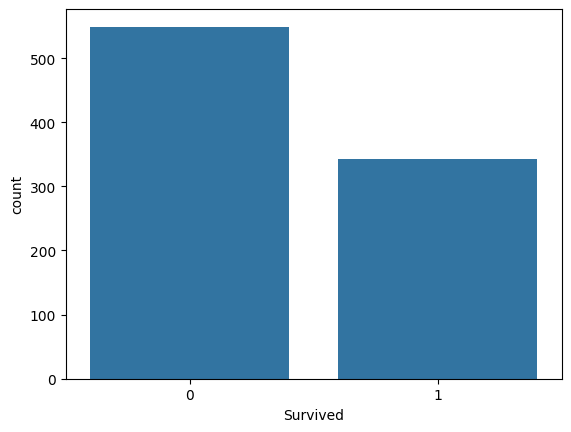

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x=df['Survived'])
dead=(df['Survived'].value_counts().values[0]/891)*100
print(f"Out of 891 passengers, {dead}% people died.")

Pclass
3    55.106622
1    24.242424
2    20.650954
Name: count, dtype: float64


Text(0.5, 1.0, 'pclass plot')

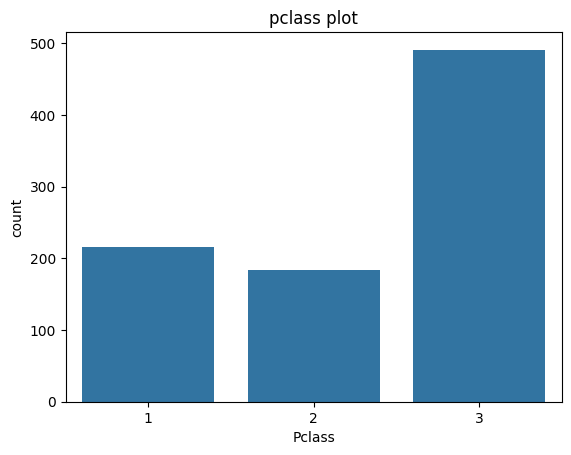

In [21]:
print((df['Pclass'].value_counts()/891)*100)
sns.countplot(x=df['Pclass'])
plt.title("pclass plot")

Sex
male      64.758698
female    35.241302
Name: count, dtype: float64


<Axes: xlabel='count', ylabel='Sex'>

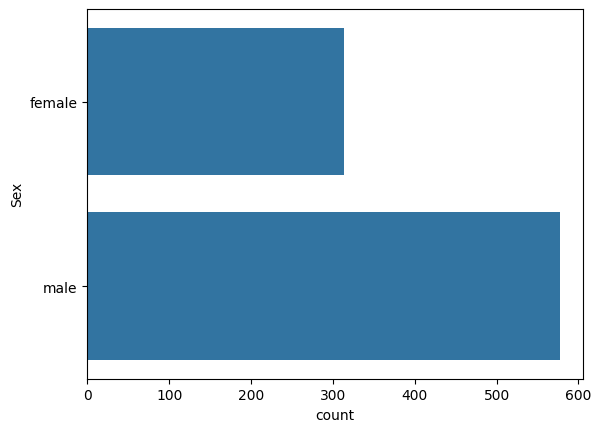

In [22]:
print((df['Sex'].value_counts()/891)*100)
sns.countplot(df['Sex'])

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64


<Axes: xlabel='SibSp', ylabel='count'>

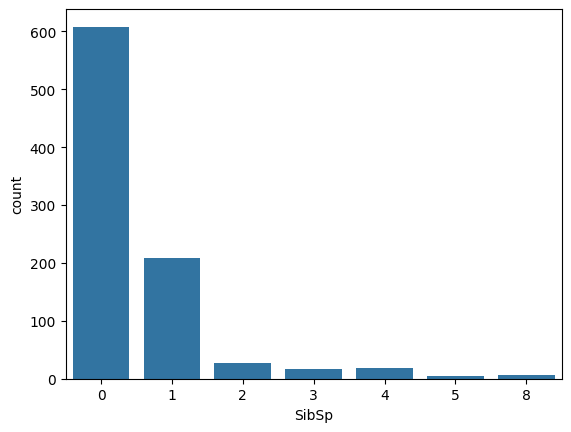

In [23]:
print(df['SibSp'].value_counts())
sns.countplot(x=df['SibSp'])

Parch
0    76.094276
1    13.243547
2     8.978676
5     0.561167
3     0.561167
4     0.448934
6     0.112233
Name: count, dtype: float64


<Axes: xlabel='Parch', ylabel='count'>

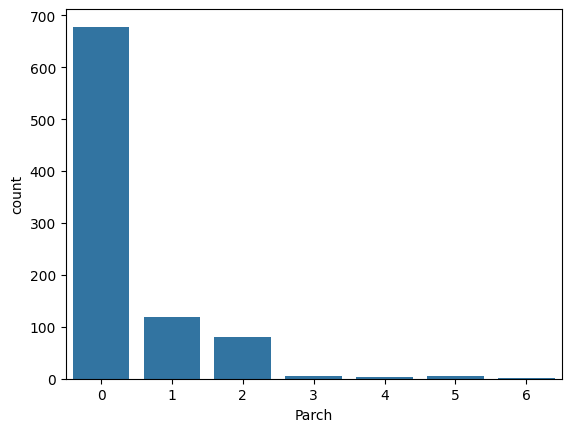

In [24]:
print((df['Parch'].value_counts()/891)*100)
sns.countplot(x=df['Parch'])

Embarked
S    72.502806
C    18.855219
Q     8.641975
Name: count, dtype: float64


<Axes: xlabel='Embarked', ylabel='count'>

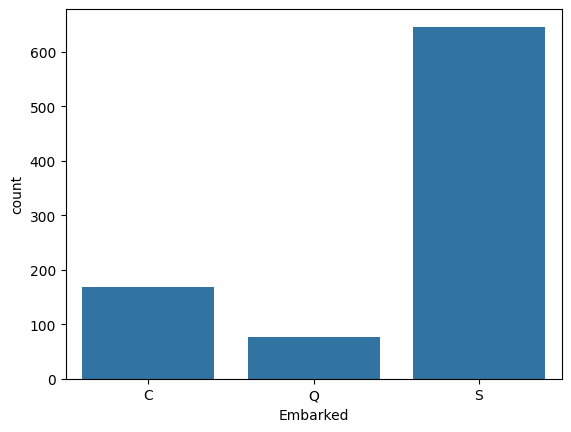

In [25]:
print((df['Embarked'].value_counts()/891)*100)
sns.countplot(x=df['Embarked'])

0.45956263424701577
0.9865867453652877


/tmp/ipykernel_16/2688210690.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Age'])


Text(0.5, 1.0, 'age plot')

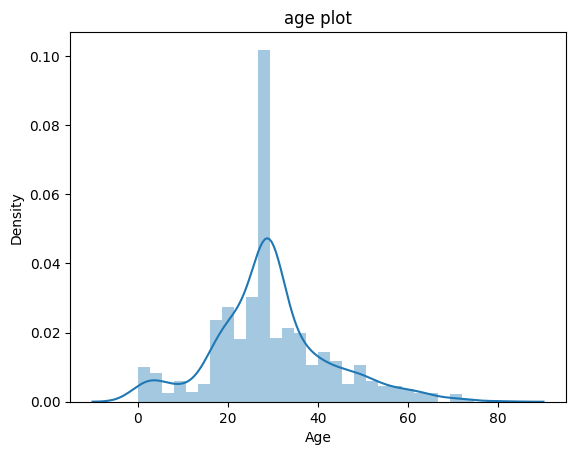

In [26]:
sns.distplot(df['Age'])
print(df['Age'].skew())
print(df['Age'].kurt())
plt.title("age plot")

<Axes: xlabel='Age'>

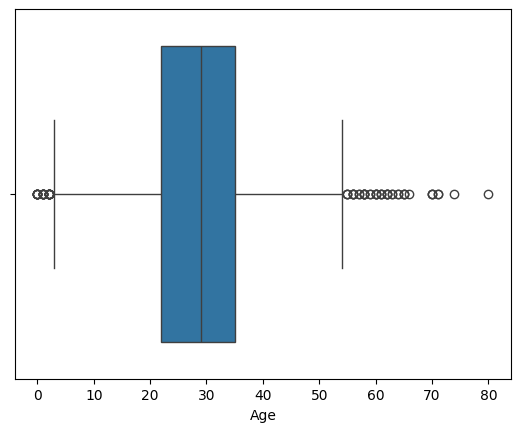

In [27]:
sns.boxplot(x=df['Age'])

In [28]:
print(df[(df['Age'] > 60) & (df['Age'] <70)].shape[0])
print(df[(df['Age'] > 70) & (df['Age'] <75)].shape[0])
print(df[(df['Age'] > 70)].shape[0])
print(df[df['Age'] < 1].shape[0])

15
3
4
7


4.787316519674893
33.39814088089868


/tmp/ipykernel_16/398100842.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Fare'])


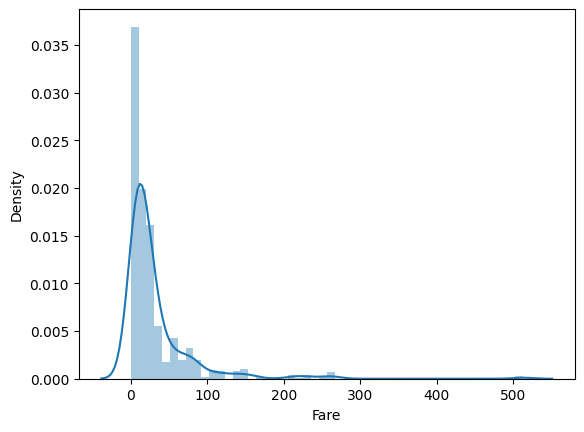

In [29]:
sns.distplot(df['Fare'])
print(df['Fare'].skew())
print(df['Fare'].kurt())

<Axes: ylabel='Fare'>

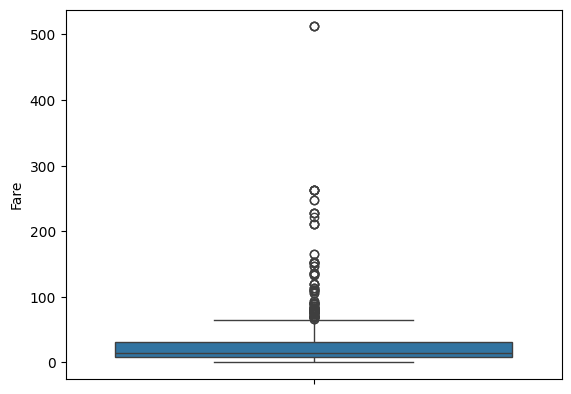

In [30]:
sns.boxplot(df['Fare'])

In [31]:
print(df[(df['Fare'] > 200) & (df['Fare'] < 300)].shape[0])
print(df[df['Fare'] > 300].shape[0])

17
3


In [32]:
pd.crosstab(df['Pclass'], df['Survived']).apply(lambda r: round((r / r.sum()) * 100, 1),axis=1)

Survived,0,1
Pclass,,
1,37.0,63.0
2,52.7,47.3
3,75.8,24.2


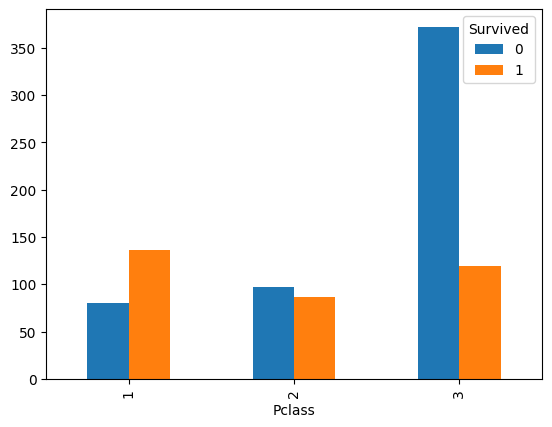

In [33]:
pd.crosstab(df['Pclass'], df['Survived']).plot(kind='bar')
plt.show()

<Axes: xlabel='Sex'>

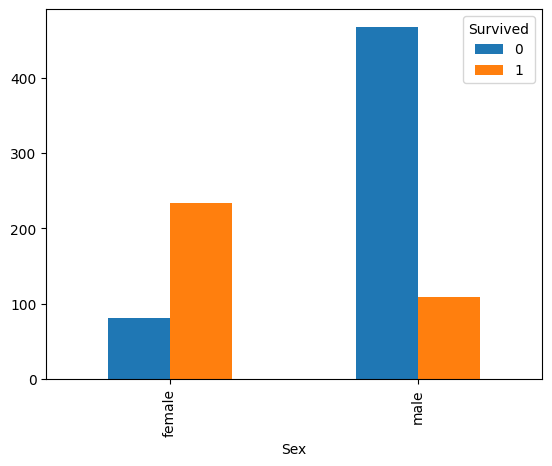

In [34]:
pd.crosstab(df['Sex'],df['Survived']).plot(kind='bar')

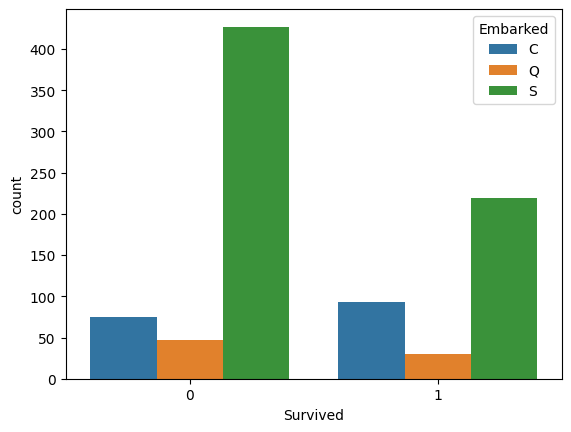

Survived,0,1
Embarked,,
C,44.6,55.4
Q,61.0,39.0
S,66.1,33.9


In [35]:
sns.countplot(x='Survived', hue='Embarked', data=df)
plt.show()
pd.crosstab(df['Embarked'],df['Survived']).apply(lambda r:round((r/r.sum())*100,1),axis=1)

In [36]:
#one concluion that c more surbvived the

/tmp/ipykernel_16/1811681565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['Survived']==0]['Age'])
/tmp/ipykernel_16/1811681565.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['Survived']==1]['Age'])


<Axes: xlabel='Age', ylabel='Density'>

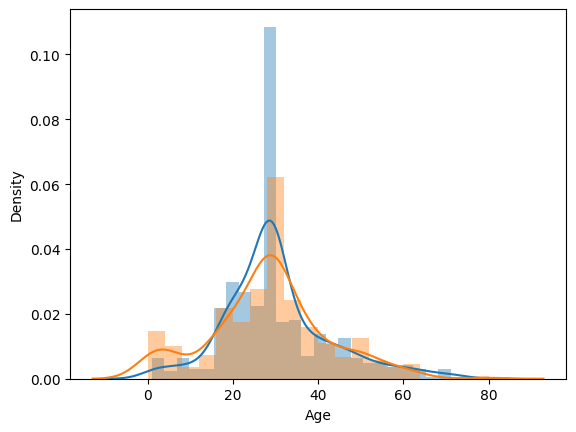

In [37]:
sns.distplot(df[df['Survived']==0]['Age'])
sns.distplot(df[df['Survived']==1]['Age'])

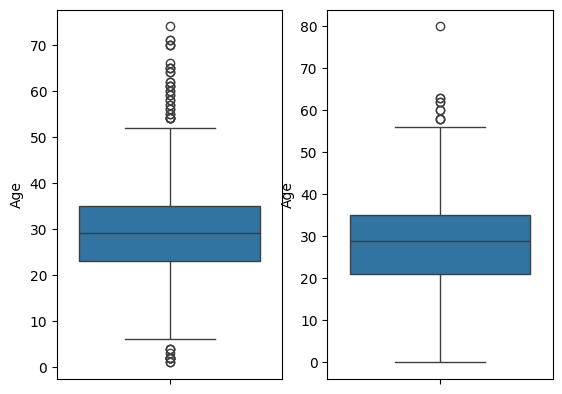

In [38]:
fig, ax = plt.subplots(1, 2)
sns.boxplot(y=df[df['Survived'] == 0]['Age'], ax=ax[0])
sns.boxplot(y=df[df['Survived'] == 1]['Age'], ax=ax[1])
plt.show()

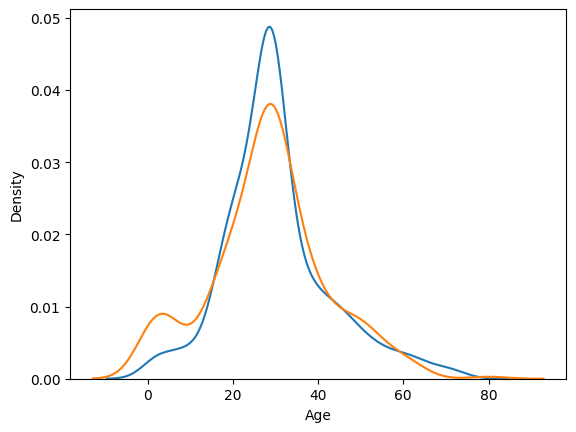

In [39]:
sns.kdeplot(df[df['Survived']==0]['Age'])
sns.kdeplot(df[df['Survived']==1]['Age'])
plt.show()

<Axes: xlabel='Age', ylabel='Density'>

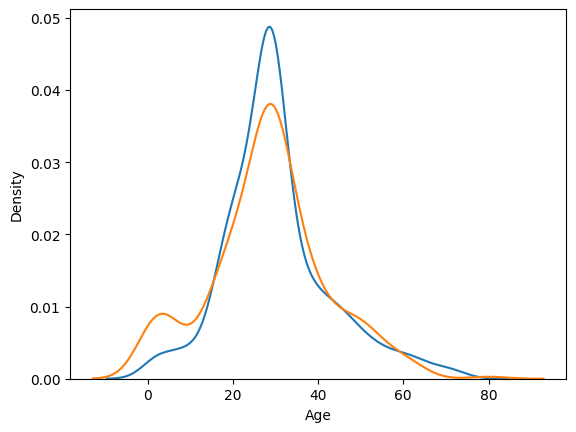

In [40]:
sns.kdeplot(df[df['Survived']==0]['Age'])
sns.kdeplot(df[df['Survived']==1]['Age'])

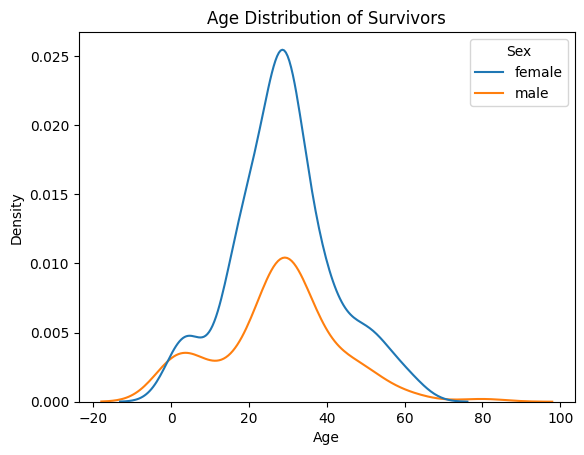

In [41]:
sns.kdeplot(data=df[df['Survived'] == 1],x='Age',hue='Sex')
plt.title('Age Distribution of Survivors')
plt.show()

Text(0.5, 1.0, 'Survived')

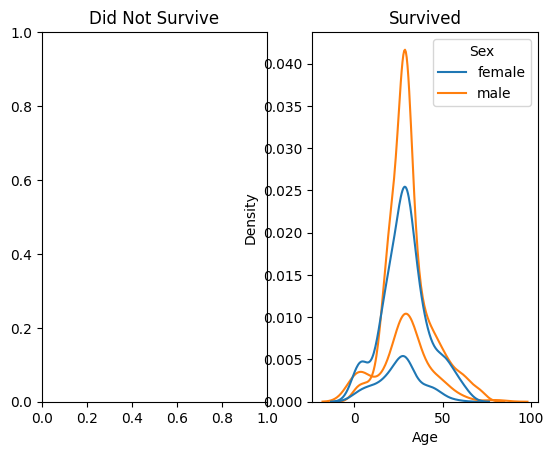

In [42]:
fig, ax = plt.subplots(1, 2)
sns.kdeplot(data=df[df['Survived'] ==0],x='Age',hue='Sex')
ax[0].set_title('Did Not Survive')
sns.kdeplot(data=df[df['Survived'] ==1],x='Age',hue='Sex')
ax[1].set_title('Survived')

<Axes: xlabel='Fare', ylabel='Density'>

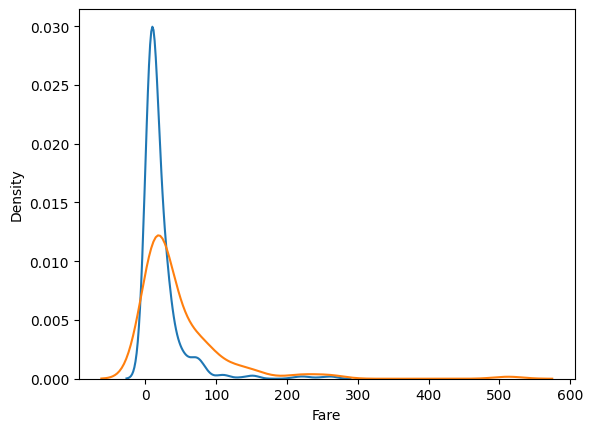

In [43]:
sns.kdeplot(df[df['Survived']==0]['Fare'])
sns.kdeplot(df[df['Survived']==1]['Fare'])

/tmp/ipykernel_16/915030334.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['Survived']==0]['Fare'])
/tmp/ipykernel_16/915030334.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['Survived']==1]['Fare'])


<Axes: xlabel='Fare', ylabel='Density'>

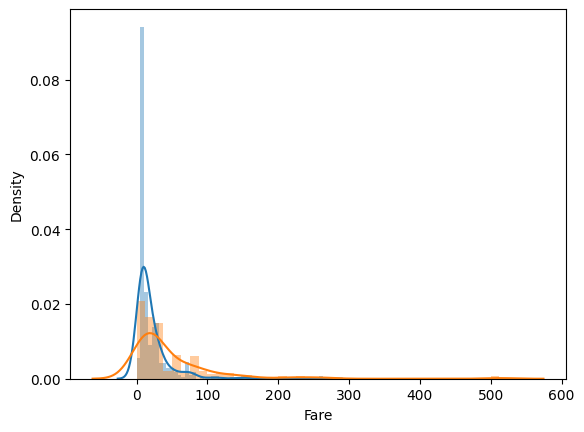

In [44]:
sns.distplot(df[df['Survived']==0]['Fare'])
sns.distplot(df[df['Survived']==1]['Fare'])

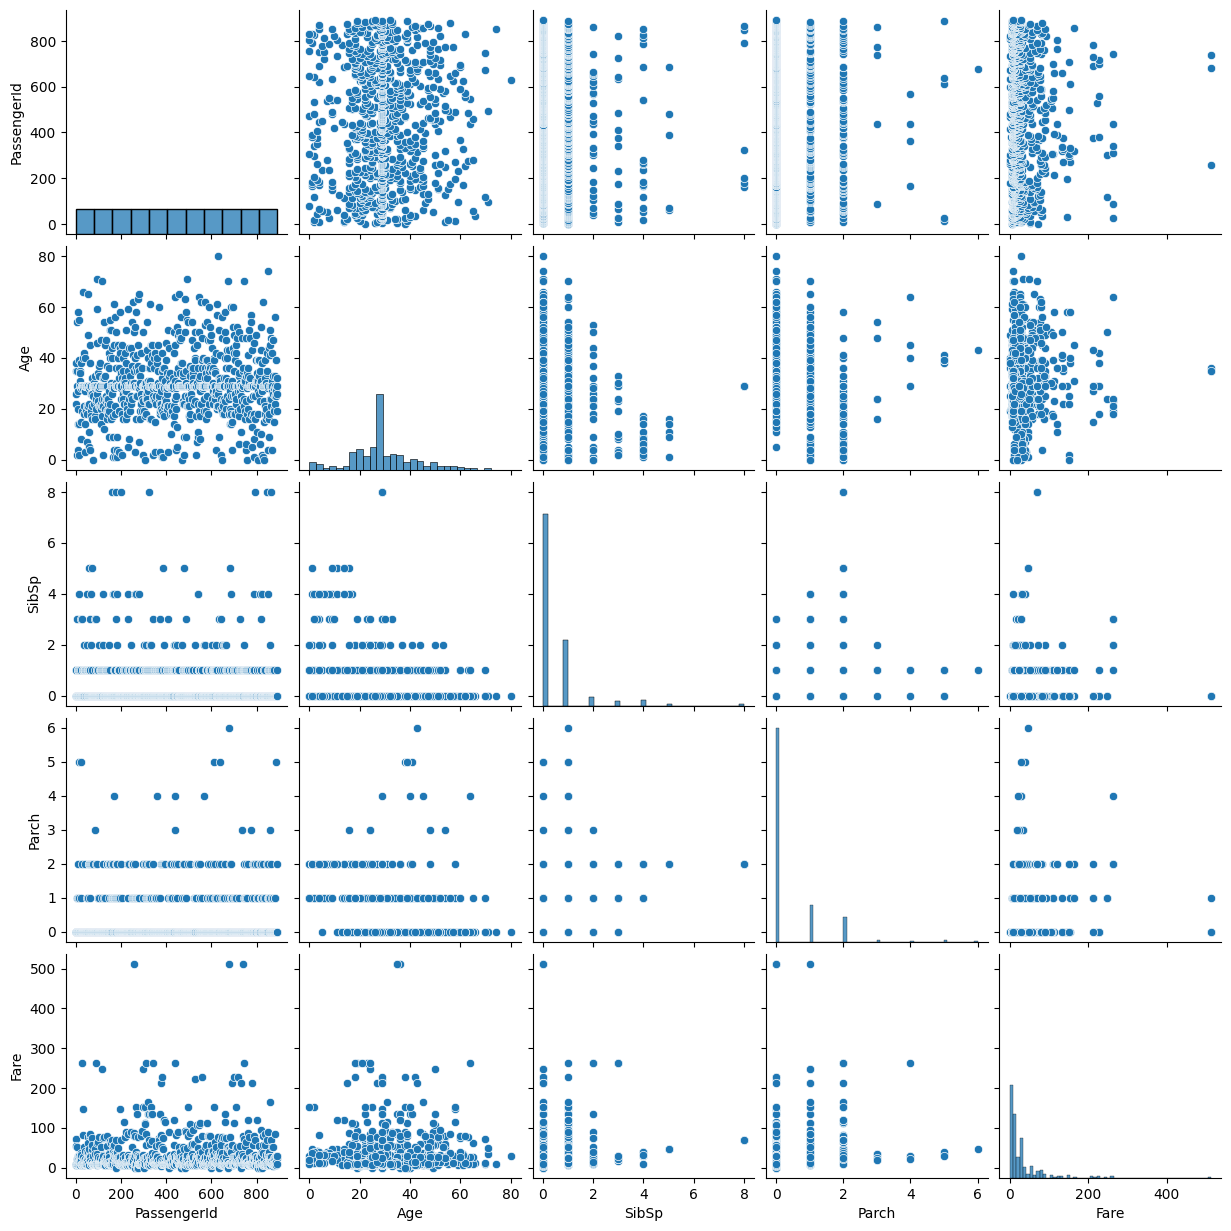

In [45]:
sns.pairplot(df)

<Axes: >

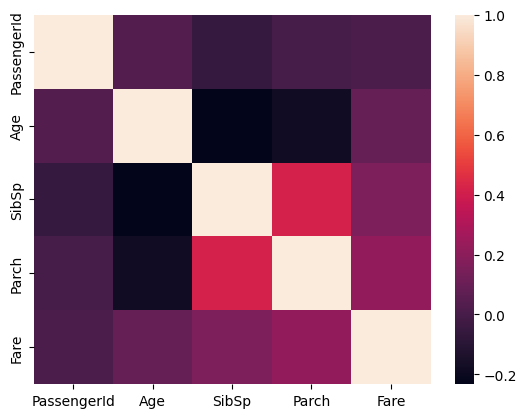

In [46]:
num_df=df.select_dtypes(include='number')
sns.heatmap(num_df.corr())

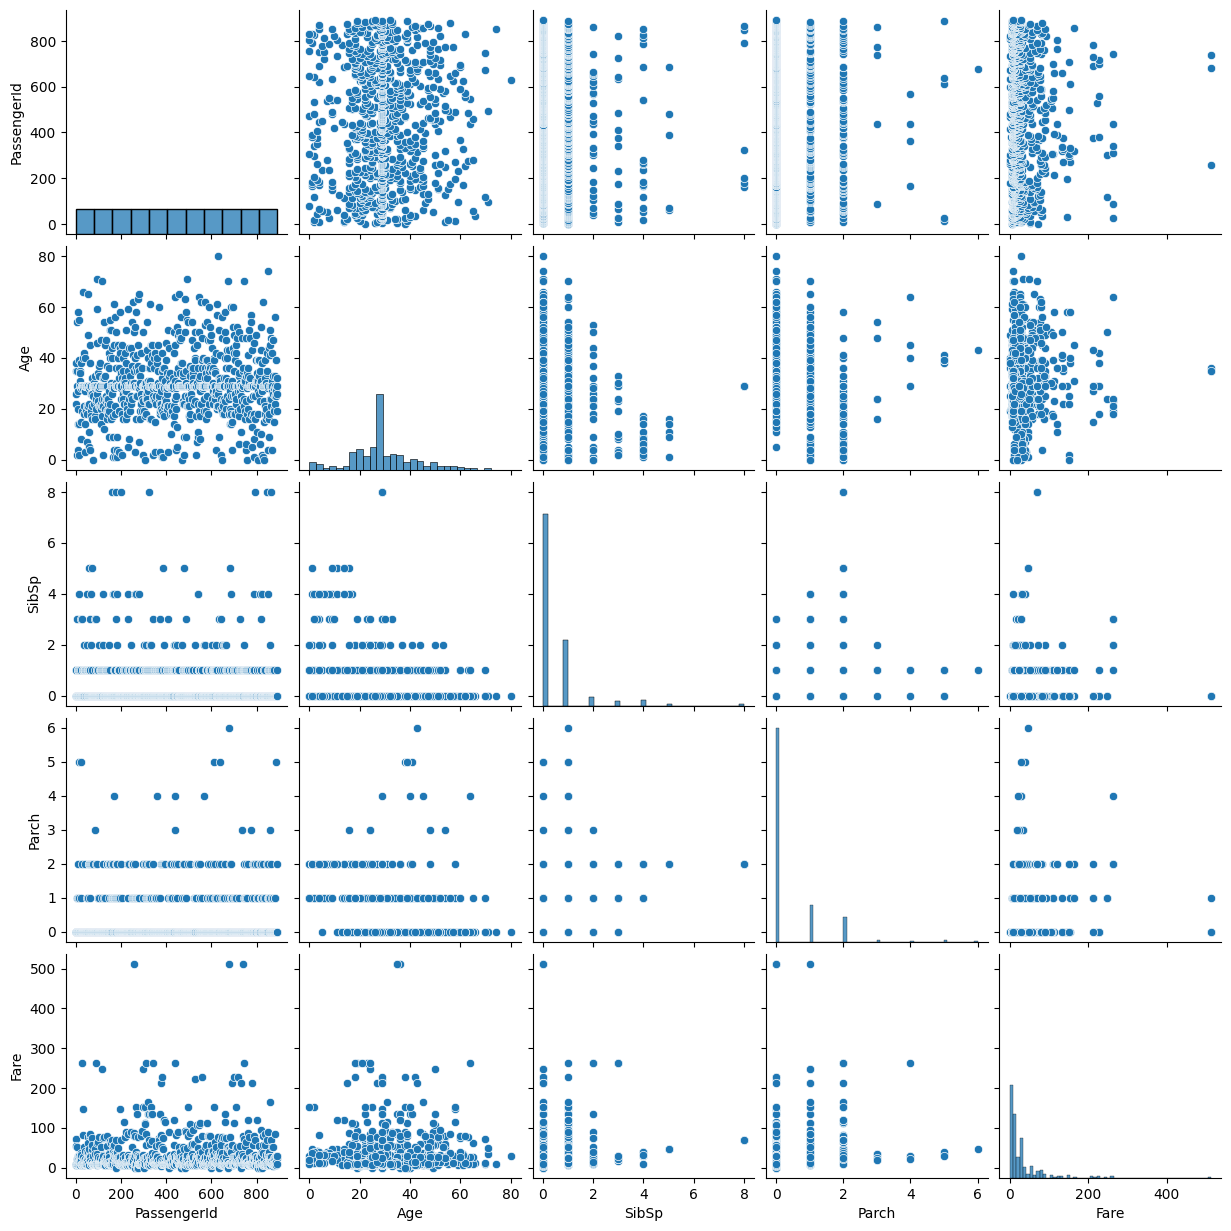

In [47]:
num_df = df.select_dtypes(include=['int64','float64'])
sns.pairplot(num_df)
plt.show()

In [48]:
df['family_size']=df['Parch']+df['SibSp']

In [49]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,family_size
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,S,0


In [50]:
def family_type(number):
    if(number==0):
        return "Alone"
    elif(number>0 and number<4):
        return "Medium"
    else:
        return "Large"
        

In [51]:
df['family_type']=df['family_size'].apply(family_type)

In [52]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,family_size,family_type
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,S,1,Medium
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C,1,Medium
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,S,0,Alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,S,1,Medium
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,S,0,Alone


In [53]:
df = df.drop(['Parch','SibSp','family_size'], axis=1)

In [54]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,family_type
0,1,0,3,"Braund, Mr. Owen Harris",male,22,A/5 21171,7.2500,S,Medium
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,PC 17599,71.2833,C,Medium
2,3,1,3,"Heikkinen, Miss. Laina",female,26,STON/O2. 3101282,7.9250,S,Alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,113803,53.1000,S,Medium
4,5,0,3,"Allen, Mr. William Henry",male,35,373450,8.0500,S,Alone


In [55]:
pd.crosstab(df['Survived'], df['family_type']).apply(lambda r: r/r.sum()*100,axis=1)

family_type,Alone,Large,Medium
Survived,,,
0,68.123862,9.471767,22.404372
1,47.660819,2.923977,49.415205


In [56]:
#normal distribution age like plot 3sd-mean to 3sd+mean
#categorical data q1-1.5iqr to q3+1.5iqr

In [57]:
mean = df['Age'].mean()
std = df['Age'].std()
df = df[(df['Age'] > mean - (3*std)) & (df['Age'] < mean + (3*std))]
df.shape

(884, 10)

In [58]:
q1 = df['Fare'].quantile(0.25)
q3 = df['Fare'].quantile(0.75)
iqr = q3 - q1
low = q1 - 1.5 * iqr
high = q3 + 1.5 * iqr
df = df[(df['Fare'] > low) & (df['Fare'] < high)]

In [59]:
new_df=df[['Pclass','Sex','Embarked','family_type']]

In [60]:
new_df.head()

,Pclass,Sex,Embarked,family_type
0,3,male,S,Medium
2,3,female,S,Alone
3,1,female,S,Medium
4,3,male,S,Alone
5,3,male,Q,Alone


In [61]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder

In [62]:
ohe = OneHotEncoder(sparse_output=False, drop='first')
encoded=ohe.fit_transform(df[['Sex','Embarked','family_type']])
encoded_df = pd.DataFrame(encoded,columns=ohe.get_feature_names_out(['Sex','Embarked','family_type']))
encoded_df.head()

,Sex_male,Embarked_Q,Embarked_S,family_type_Large,family_type_Medium
0,1.0,0.0,1.0,0.0,1.0
1,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,1.0,0.0,1.0
3,1.0,0.0,1.0,0.0,0.0
4,1.0,1.0,0.0,0.0,0.0


In [63]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Sex_encoded'] = le.fit_transform(df['Sex'])
df['Embarked_encoded'] = le.fit_transform(df['Embarked'])
df['family_type_encoded'] = le.fit_transform(df['family_type'])
df[['Sex','Sex_encoded','Embarked','Embarked_encoded','family_type','family_type_encoded']].head()

,Sex,Sex_encoded,Embarked,Embarked_encoded,family_type,family_type_encoded
0,male,1,S,2,Medium,2
2,female,0,S,2,Alone,0
3,female,0,S,2,Medium,2
4,male,1,S,2,Alone,0
5,male,1,Q,1,Alone,0


In [64]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,family_type,Sex_encoded,Embarked_encoded,family_type_encoded
0,1,0,3,"Braund, Mr. Owen Harris",male,22,A/5 21171,7.2500,S,Medium,1,2,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26,STON/O2. 3101282,7.9250,S,Alone,0,2,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,113803,53.1000,S,Medium,0,2,2
4,5,0,3,"Allen, Mr. William Henry",male,35,373450,8.0500,S,Alone,1,2,0
5,6,0,3,"Moran, Mr. James",male,29,330877,8.4583,Q,Alone,1,1,0


In [65]:
df.drop(columns=['Embarked','Sex','family_type','PassengerId'],inplace=True)

In [66]:
df = pd.concat([df, encoded_df], axis=1)
df.head()

,Survived,Pclass,Name,Age,Ticket,Fare,Sex_encoded,Embarked_encoded,family_type_encoded,Sex_male,Embarked_Q,Embarked_S,family_type_Large,family_type_Medium
0,0,3,"Braund, Mr. Owen Harris",22.0,A/5 21171,7.2500,1.0,2.0,2.0,1.0,0.0,1.0,0.0,1.0
2,1,3,"Heikkinen, Miss. Laina",26.0,STON/O2. 3101282,7.9250,0.0,2.0,0.0,0.0,0.0,1.0,0.0,1.0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,113803,53.1000,0.0,2.0,2.0,1.0,0.0,1.0,0.0,0.0
4,0,3,"Allen, Mr. William Henry",35.0,373450,8.0500,1.0,2.0,0.0,1.0,1.0,0.0,0.0,0.0
5,0,3,"Moran, Mr. James",29.0,330877,8.4583,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


In [67]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df['Title'].value_counts()

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_16/2446957854.py:1: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


Title
Mr          472
Miss        143
Mrs          97
Master       36
Rev           6
Dr            5
Col           2
Major         2
Don           1
Ms            1
Lady          1
Sir           1
Mlle          1
Jonkheer      1
Name: count, dtype: int64

In [68]:
rare = ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona']
df['Title'] = df['Title'].replace(rare, 'Rare')

In [69]:
title_encoded = pd.get_dummies(df['Title'], drop_first=True)
df = pd.concat([df, title_encoded], axis=1)

In [70]:
df.drop(['Name','Title'], axis=1, inplace=True)

<Axes: >

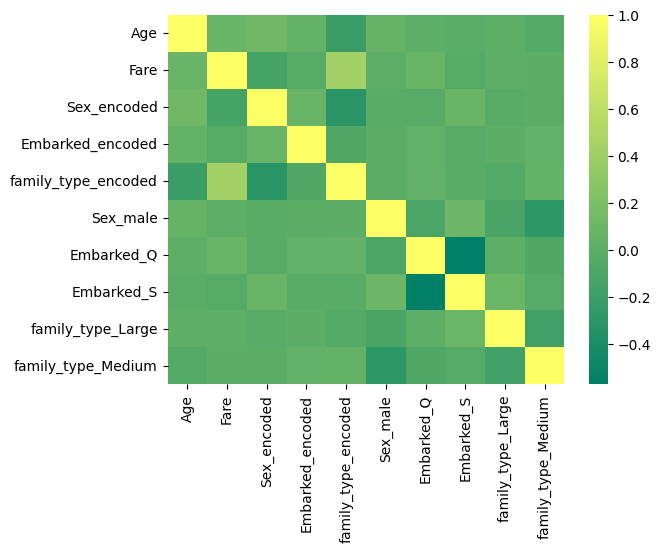

In [71]:
newnum_df=df.select_dtypes(include='number')
sns.heatmap(newnum_df.corr(),cmap='summer')

In [72]:
#Survival rate was approximately 38%, while about 62% did not survive.
#Survival on the Titanic was heavily influenced by social status, gender, age group, and economic class. Female passengers, children, first-class travelers, and passengers paying higher fares had significantly greater chances of survival, while third-class male passengers traveling alone faced the highest risk.

In [73]:
#finally ho gya....